# Log

- Decode with all ROIs (Global)
- Subject 8 is subject 7 without smoothing in preprocessing. 

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

In [3]:
mask.get_fdata().shape

(91, 109, 91)

# Resample MNI mask

In [3]:
temp_nii_path = r'F:\yujun\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

(79, 95, 79)

# Load Kastner mask

In [4]:
mask_temp= nib.load(f'F:\yujun\projects\data\masks\Kastner\IPS.img')

### Thresholding method (Abandoned)

In [274]:
roi_id = np.arange(1, 26)

roi_labels = ['V1v',	    
 'V1d',	   
 'V2v',   
 'V2d',	   
 'V3v',	    
 'V3d',	    
 'hV4',	  
 'VO1',	    
 'VO2',	    
 'PHC1',	    
 'PHC2',	    
 'MST',	    
 'hMT',	   
 'LO2',	    
 'LO1',	   
 'V3b',	    
 'V3a',	  
 'IPS0',	   
 'IPS1',	    
 'IPS2',	    
 'IPS3',	  
 'IPS4',	  
 'IPS5',	  
 'SPL1',	 
 'FEF'	]

roi_bin = []
roi_masks = []

for i in range(len(roi_id)):
    kastner_dir = 'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all'
    kastner_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_lh.nii.gz')
    kastner_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_rh.nii.gz')
    kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
    kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)
    # Resample Kastner mask
    kastner_resample = resample_img(kastner_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    # Create a binary mask where values > 0 are set to 1 and other values are set to 0
    kastner_resample_bin = np.where(kastner_resample.get_fdata() > 10, 1, 0)
    roi_bin.append(kastner_resample_bin)
    roi_masks.append(nib.Nifti1Image(kastner_resample_bin, temp_nii_data.affine))

for roi in roi_bin:
# print(f'The ROI mask dimension is: {kastner_resample_bin.shape}')
# total_voxels_count = kastner_resample_bin.shape[0] * kastner_resample_bin.shape[1] * kastner_resample_bin.shape[2]
# print(f'The total number of voxels is: {total_voxels_count}')
    print(f'There are {np.count_nonzero(roi)} voxels in the ROI mask')

roi_masks = dict(zip(roi_labels, roi_masks))

There are 2497 voxels in the ROI mask
There are 2389 voxels in the ROI mask
There are 2295 voxels in the ROI mask
There are 2174 voxels in the ROI mask
There are 1762 voxels in the ROI mask
There are 2130 voxels in the ROI mask
There are 1561 voxels in the ROI mask
There are 873 voxels in the ROI mask
There are 916 voxels in the ROI mask
There are 826 voxels in the ROI mask
There are 957 voxels in the ROI mask
There are 772 voxels in the ROI mask
There are 1249 voxels in the ROI mask
There are 1085 voxels in the ROI mask
There are 1368 voxels in the ROI mask
There are 1196 voxels in the ROI mask
There are 1911 voxels in the ROI mask
There are 1978 voxels in the ROI mask
There are 1649 voxels in the ROI mask
There are 1585 voxels in the ROI mask
There are 1244 voxels in the ROI mask
There are 1307 voxels in the ROI mask
There are 1166 voxels in the ROI mask
There are 1434 voxels in the ROI mask
There are 2688 voxels in the ROI mask


### Labeling method

In [10]:
kastner_maxprob_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_lh.nii.gz')
kastner_maxprob_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_rh.nii.gz')   
kastner_maxprob_combine = kastner_maxprob_l.get_fdata() + kastner_maxprob_r.get_fdata()
kastner_kastner_maxprob_combine_nii = nib.Nifti1Image(kastner_maxprob_combine, kastner_maxprob_r.affine)
kastner_maxprob_resample = resample_img(kastner_kastner_maxprob_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
# Round the values to the nearest integer to preserve ROI labels
kastner_maxprob_data = np.round(kastner_maxprob_resample.get_fdata())
kastner_maxprob_resample_nii = nib.Nifti1Image(kastner_maxprob_data, kastner_maxprob_r.affine)

print("Original: " , kastner_maxprob_combine.shape, '\n', "Resampled: ", kastner_maxprob_resample.get_fdata().shape)

Original:  (182, 218, 182) 
 Resampled:  (79, 95, 79)


In [12]:
np.save( 'F:\yujun\projects\data\masks\kastner_maxprob_data.npy',kastner_maxprob_data)
nib.save(kastner_maxprob_resample_nii, 'F:\yujun\projects\data\masks\kastner79.nii')

In [13]:
kastner_maxprob_resample_nii = nib.load("F:\yujun\projects\data\masks\kastner79.nii")
kastner_maxprob_data = np.load('F:\yujun\projects\data\masks\kastner_maxprob_data.npy')

In [14]:
np.unique(kastner_maxprob_data)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.])

In [18]:
roi_labels = ['V1v',	    
 'V1d',	   
 'V2v',   
 'V2d',	   
 'V3v',	    
 'V3d',	    
 'hV4',	  
 'VO1',	    
 'VO2',	    
 'PHC1',	    
 'PHC2',	    
 'MST',	    # neglected 
 'hMT',	   
 'LO2',	    
 'LO1',	   
 'V3b',	    
 'V3a',	  
 'IPS0',	   # combine all IPS
 'IPS1',	    
 'IPS2',	    
 'IPS3',	  
 'IPS4',	  
 'IPS5',	  
 'SPL1',	  # neglected 
 'FEF'	# neglected 
 ]
# Separate each ROI into its own mask and save to a dictionary
roi_masks = {}
for label_id in range(1, 26):  # Assuming ROI labels are 1 through 25
    roi_mask_data = (kastner_maxprob_data == label_id).astype(int)
    roi_mask_img = nib.Nifti1Image(roi_mask_data, affine=temp_nii_data.affine)
    
    # Example of saving the mask; adjust filenames as needed
    roi_name = roi_labels[label_id-1]
    # nib.save(roi_mask_img, f'{roi_name}.nii.gz')
    
    # Store in dictionary
    roi_masks[roi_name] = roi_mask_img

In [19]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165
MST (79, 95, 79) 3
hMT (79, 95, 79) 86
LO2 (79, 95, 79) 125
LO1 (79, 95, 79) 324
V3b (79, 95, 79) 263
V3a (79, 95, 79) 554
IPS0 (79, 95, 79) 499
IPS1 (79, 95, 79) 248
IPS2 (79, 95, 79) 113
IPS3 (79, 95, 79) 86
IPS4 (79, 95, 79) 21
IPS5 (79, 95, 79) 6
SPL1 (79, 95, 79) 11
FEF (79, 95, 79) 7


Combine IPS

In [48]:
roi_labels = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2',
              'PHC1', 'PHC2', 'MST', 'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
              'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5', 'SPL1', 'FEF']

# Initialize an empty dictionary to store ROI masks
roi_masks = {}

# Initialize an empty mask for accumulating all IPS masks
combined_IPS_mask = np.zeros(kastner_maxprob_data.shape, dtype=bool)

# Process each ROI
for label_id, roi_name in enumerate(roi_labels, start=1):
    # Skip the ROIs that should not be individual masks
    if roi_name in ['hMT','MST', 'SPL1', 'FEF']:
        continue

    # Check if this ROI is one of the 'IPS' ROIs to combine them
    if 'IPS' in roi_name:
        # Accumulate the IPS masks
        combined_IPS_mask |= (kastner_maxprob_data == label_id)
    else:
        # Handle non-IPS ROIs normally
        roi_mask_data = (kastner_maxprob_data == label_id).astype(int)
        roi_mask_img = nib.Nifti1Image(roi_mask_data, affine=temp_nii_data.affine)
        # Store in dictionary
        roi_masks[roi_name] = roi_mask_img
        # Optionally save the mask
        # nib.save(roi_mask_img, f'{roi_name}.nii.gz')

# After accumulating the IPS masks, convert to int and store/save
if combined_IPS_mask.any():
    combined_IPS_mask_img = nib.Nifti1Image(combined_IPS_mask.astype(int), affine=temp_nii_data.affine)
    roi_masks['IPS'] = combined_IPS_mask_img
    # Optionally save the combined IPS mask
    # nib.save(combined_IPS_mask_img, 'Combined_IPS.nii.gz')

# 'roi_masks' now contains individual ROI masks and a combined mask for all 'IPS' ROIs

In [49]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165
LO2 (79, 95, 79) 125
LO1 (79, 95, 79) 324
V3b (79, 95, 79) 263
V3a (79, 95, 79) 554
IPS (79, 95, 79) 973


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of 


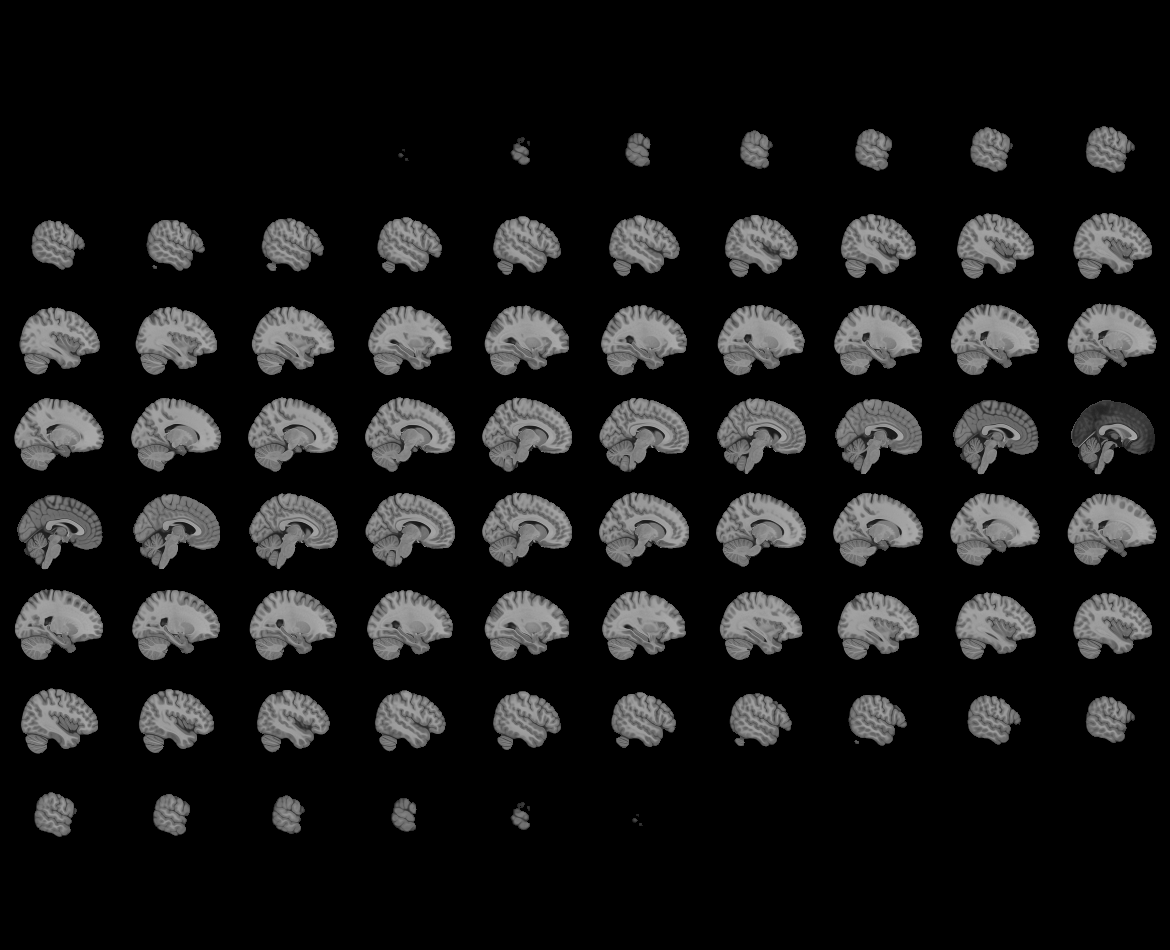
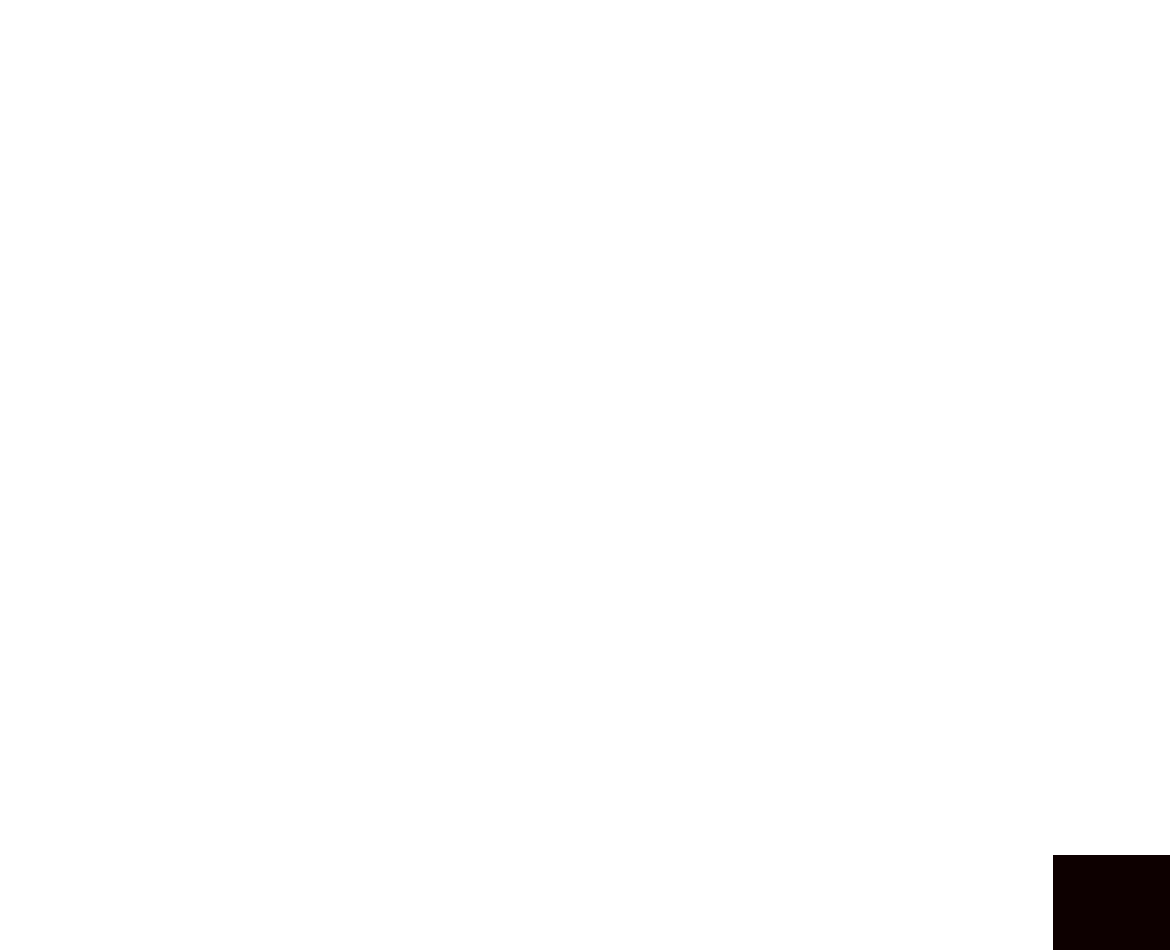

In [296]:
roi = 'V1v'
view = plotting.view_img(roi_masks[roi], title = roi)
view

In [61]:
np.save("./kastner_dict.npy", roi_masks)

## Load AAL3 mask

In [199]:
aal3_label = [
 'ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
#  'CingulateAnt',
#  'CingulateMid',
#  'CingulatePost',
 'Cuneus',
 'Fusiform',
 'Hippocampus',
 'Insula',
 'Lingual',
 'ParaHippocampal',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'ThalPuL'
]

aal3_bins = []
aal3_masks = []

for i in range(len(aal3_label)):
    aal3_nii = nib.load(f'F:\yujun\projects\data\masks\AAL3\\new\{aal3_label[i]}.nii.gz')
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    aal3_bins.append(aal3_bin)

In [200]:
print(f"original size: {aal3_nii.get_fdata().shape}")
print(f"resampled size: {aal3_bin.shape}")

original size: (91, 109, 91)
resampled size: (79, 95, 79)


In [201]:
aal3_dict = dict(zip(aal3_label, aal3_bins))

In [226]:
np.save("./aal3_dict.npy", aal3_dict)

Combine ROIs

In [227]:
rois_dict = kastner_dict
rois_dict.update(aal3_dict)
len(rois_dict)

43

In [246]:
np.save("./rois_dict.npy", rois_dict)

# Load beta series and apply MNI mask

Define beta ids, clean out movement and baseline betas

In [4]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)

In [5]:
beta_id

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
        182, 183, 184, 185, 186, 187, 188, 189, 190

In [10]:
dataDir = '../GLM_singletrial/betas/'
subs = os.listdir(dataDir)
# subs =  ['Sub7',
#  'Sub7_2207',
#  'Sub7_archive',
#  'Sub7_unsmooth',
#  'Sub7_2207_longtrialnames']
subs =  [  
    'Sub1',
    'Sub2',
    'Sub3',
    'Sub4',
    'Sub5',
    'Sub6',
    'Sub7',
    'Sub1_2207_longtrialnames',
    'Sub2_2207_longtrialnames',
    'Sub3_2207_longtrialnames',
    'Sub4_2207_longtrialnames',
    'Sub5_2207_longtrialnames',
    'Sub6_2207_longtrialnames',
    'Sub7_2207_longtrialnames']
subs

['Sub1',
 'Sub2',
 'Sub3',
 'Sub4',
 'Sub5',
 'Sub6',
 'Sub7',
 'Sub1_2207_longtrialnames',
 'Sub2_2207_longtrialnames',
 'Sub3_2207_longtrialnames',
 'Sub4_2207_longtrialnames',
 'Sub5_2207_longtrialnames',
 'Sub6_2207_longtrialnames',
 'Sub7_2207_longtrialnames']

In [11]:
beta_series = []
z_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)
    # Extract the IDs from the filenames
    file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
    # Filter the filenames based on the ID list
    selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
    # print(f'Number of betas for the subject: {len(selected_filenames)}')
    
    sub_beta_series = []
    sub_z_series = []
    for i in tqdm(range(len(selected_filenames))):
        # Load the NIfTI file
        file_path = os.path.join(dataDir, sub, selected_filenames[i])
        nii_data = nib.load(file_path)
        # Apply the mask to the NIfTI image
        masked_data = masking.apply_mask(nii_data, resampled_mask)
        # Get the mask's indices in the original 3D shape
        mask_indices = np.where(resampled_mask.get_fdata())
        # Create a new 3D array filled with zeros
        reshaped_data = np.empty(nii_data.shape)
        reshaped_data[:] = np.nan
        # Fill the new 3D array with the values from the masked data
        reshaped_data[mask_indices] = masked_data
        sub_beta_series.append(reshaped_data)

    sub_beta_arrays = np.array(sub_beta_series)
    beta_series.append(sub_beta_arrays)
    # z-score standardization
    # Calculate the mean and standard deviation along axis 0
    mean = sub_beta_arrays.mean(axis=0)
    std = sub_beta_arrays.std(axis=0)
    # Avoid division by zero for voxels with zero variance
    std[std == 0] = 1
    # Perform z-score standardization along axis 0
    sub_z_arr = (sub_beta_arrays - mean) / std
    z_series.append(sub_z_arr)


  0%|          | 0/600 [00:00<?, ?it/s]

100%|██████████| 600/600 [03:20<00:00,  2.99it/s]


In [16]:
selected_filenames

['beta_0001.nii',
 'beta_0002.nii',
 'beta_0003.nii',
 'beta_0004.nii',
 'beta_0005.nii',
 'beta_0006.nii',
 'beta_0007.nii',
 'beta_0008.nii',
 'beta_0009.nii',
 'beta_0010.nii',
 'beta_0011.nii',
 'beta_0012.nii',
 'beta_0013.nii',
 'beta_0014.nii',
 'beta_0015.nii',
 'beta_0016.nii',
 'beta_0017.nii',
 'beta_0018.nii',
 'beta_0019.nii',
 'beta_0020.nii',
 'beta_0021.nii',
 'beta_0022.nii',
 'beta_0023.nii',
 'beta_0024.nii',
 'beta_0025.nii',
 'beta_0026.nii',
 'beta_0027.nii',
 'beta_0028.nii',
 'beta_0029.nii',
 'beta_0030.nii',
 'beta_0031.nii',
 'beta_0032.nii',
 'beta_0033.nii',
 'beta_0034.nii',
 'beta_0035.nii',
 'beta_0036.nii',
 'beta_0037.nii',
 'beta_0038.nii',
 'beta_0039.nii',
 'beta_0040.nii',
 'beta_0041.nii',
 'beta_0042.nii',
 'beta_0043.nii',
 'beta_0044.nii',
 'beta_0045.nii',
 'beta_0046.nii',
 'beta_0047.nii',
 'beta_0048.nii',
 'beta_0049.nii',
 'beta_0050.nii',
 'beta_0051.nii',
 'beta_0052.nii',
 'beta_0053.nii',
 'beta_0054.nii',
 'beta_0055.nii',
 'beta_005

In [38]:
beta_series_arr = np.array(beta_series)
beta_series_arr.shape
z_series_arr = np.array(z_series)
# z_series_arr = np.nan_to_num(z_series_arr, nan=0)
z_series_arr.shape

(14, 600, 79, 95, 79)

Save beta and Z series

In [ ]:
np.save("./data/beta_series.npy", beta_series_arr)
np.save("./data/z_series_arr.npy", z_series_arr)

In [69]:
np.save("./data/beta_series_sub4.npy", beta_series_arr[3])
np.save("./data/z_series_arr_sub4.npy", z_series_arr[3])

Load beta and Z series

In [70]:
beta_series_arr = np.load("./data/beta_series.npy")
# z_series_arr = np.load("./data/z_series_arr.npy")

In [24]:
beta_series_arr.shape

(7, 600, 79, 95, 79)

Plot beta distribution

(array([1.1000000e+01, 1.0300000e+02, 1.6870000e+03, 2.3813000e+04,
        6.1375200e+05, 9.7634905e+07, 3.8637810e+07, 1.3600300e+05,
        3.1500000e+03, 1.6600000e+02]),
 array([-46.01792145, -38.18391685, -30.34991226, -22.51590767,
        -14.68190308,  -6.84789848,   0.98610611,   8.8201107 ,
         16.6541153 ,  24.48811989,  32.32212448]),
 <BarContainer object of 10 artists>)

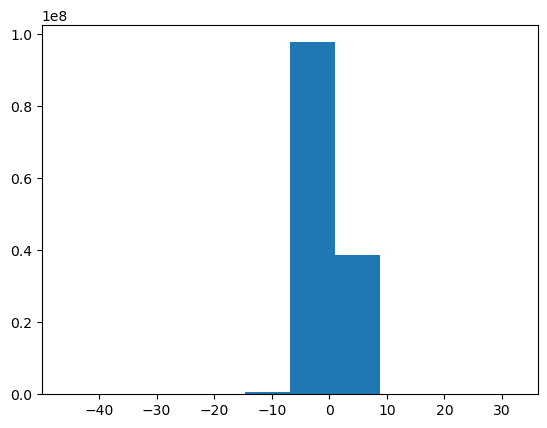

In [82]:
plt.hist(beta_series.flatten().T)

(array([1.0800000e+02, 1.7480000e+03, 5.7554000e+04, 4.2706360e+06,
        5.2309722e+07, 6.8240246e+07, 9.1756980e+06, 1.7052500e+05,
        2.6390000e+03, 1.2400000e+02]),
 array([-8.49868614, -6.83733216, -5.17597819, -3.51462421, -1.85327023,
        -0.19191625,  1.46943773,  3.13079171,  4.79214569,  6.45349966,
         8.11485364]),
 <BarContainer object of 10 artists>)

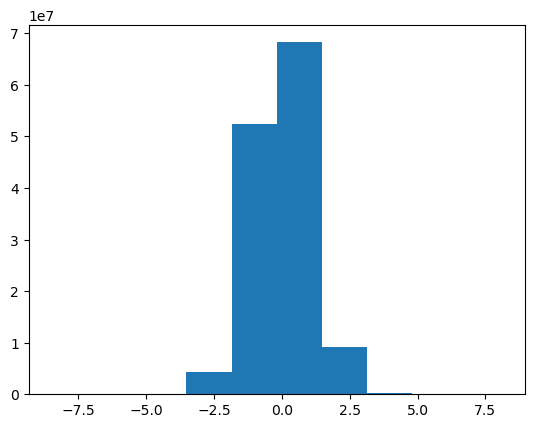

In [83]:
plt.hist(sub_z_series.flatten().T)

(array([  265.,  3467., 12031., 37475., 61555., 57589., 32328.,  8833.,
         1254.,    65.]),
 array([-3.75044789, -3.01719769, -2.2839475 , -1.5506973 , -0.81744711,
        -0.08419691,  0.64905329,  1.38230348,  2.11555368,  2.84880387,
         3.58205407]),
 <BarContainer object of 10 artists>)

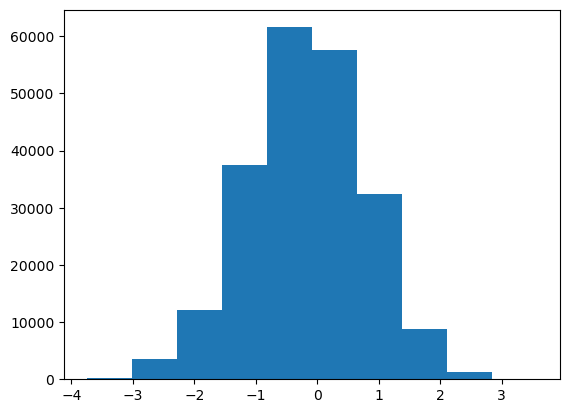

In [26]:
plt.hist(z_series_arr[0,110,:].flatten().T)

In [36]:
p1 = np.count_nonzero(np.isnan(beta_series_arr))/(np.count_nonzero(np.isnan(beta_series_arr))+np.count_nonzero(~np.isnan(beta_series_arr)))
print(f"nan ratio in beta series: {p1}")

nan ratio in beta series: 0.6147395407281222


In [37]:
p2 = np.count_nonzero(np.isnan(z_series_arr))/(np.count_nonzero(np.isnan(z_series_arr))+np.count_nonzero(~np.isnan(z_series_arr)))
print(f"nan ratio in z series: {p2}")

nan ratio in z series: 0.6290446513656357


### Extract global feature from AAL3 ROI

In [13]:
aal3_nii = nib.load("F:\yujun\projects\data\masks\AAL3\AAL3v1.nii")
aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
# aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)

In [14]:
aal3_resample.get_fdata().shape

(79, 95, 79)

In [15]:
np.unique(aal3_resample.get_fdata())

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,
        46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,
        57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,
        68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,
        79.,  80.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,
        92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100., 101., 102.,
       103., 104., 105., 106., 107., 108., 109., 110., 111., 112., 113.,
       114., 115., 116., 117., 118., 119., 120., 121., 122., 123., 124.,
       125., 126., 127., 128., 129., 130., 131., 132., 133., 134., 135.,
       136., 137., 138., 139., 140., 141., 142., 143., 144., 145., 146.,
       147., 148., 149., 150., 151., 152., 153., 15

In [16]:
int(np.max(aal3_resample.get_fdata()))

170

In [77]:
# series = z_series_arr[:7]
series = beta_series_arr[:7]

In [78]:
# Define the excluded ROI indices
excluded_rois = [34, 35, 80, 81]

# Initialize roi_betas_arr as a list
roi_betas_arr = []

# Iterate over subjects
for subj_idx in range(series.shape[0]):
    # Initialize subject-specific array
    subj_betas_arr = []
    
    # Iterate over trials
    for trial_idx in tqdm(range(series.shape[1])):
        # Initialize trial-specific array
        trial_betas_arr = []
        
        # Iterate over ROIs
        for roi_idx in range(int(np.max(aal3_resample.get_fdata()))):
            # Check if the current ROI index is excluded
            if roi_idx  in excluded_rois:
                continue
            
            # Apply mask to extract beta values for the current ROI
            masked_beta_values = series[subj_idx, trial_idx][aal3_resample.get_fdata() == (roi_idx + 1)]
            # Calculate the mean of beta values for the current ROI
            roi_mean_beta = np.nanmean(masked_beta_values)
            # Append the mean beta value to the trial-specific array
            trial_betas_arr.append(roi_mean_beta)
        
        # Append the trial-specific array to the subject-specific array
        subj_betas_arr.append(trial_betas_arr)
    
    # Append the subject-specific array to the list
    roi_betas_arr.append(subj_betas_arr)

# Convert the list to a numpy array
roi_betas_arr = np.array(roi_betas_arr)

100%|██████████| 600/600 [02:25<00:00,  4.12it/s]


In [42]:
roi_betas_arr.shape

(14, 600, 166)

In [71]:
# roi_z_arr = roi_betas_arr
roi_betas_arr = roi_betas_arr

(600, 166)

Beta trial plot

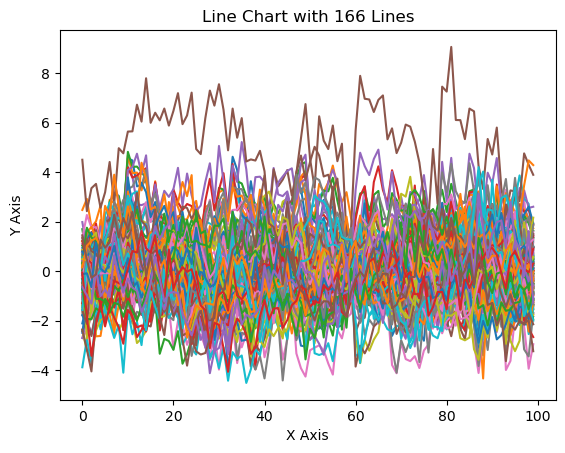

In [80]:
sub_beta_series = roi_betas_arr[3, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

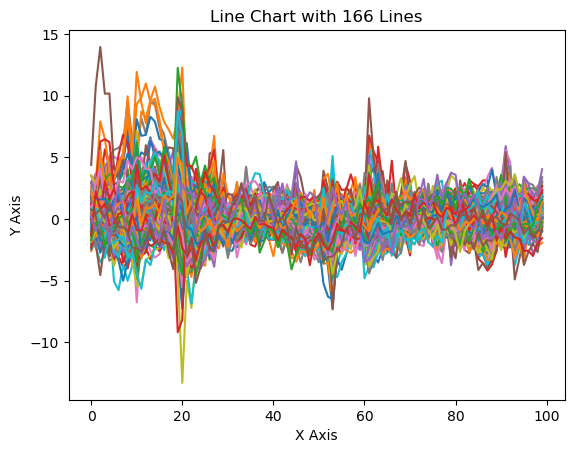

In [81]:
sub_beta_series = roi_betas_arr[4, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

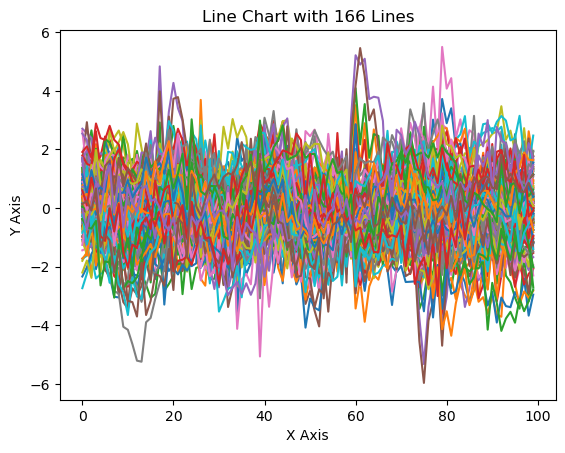

In [82]:
sub_beta_series = roi_betas_arr[5, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

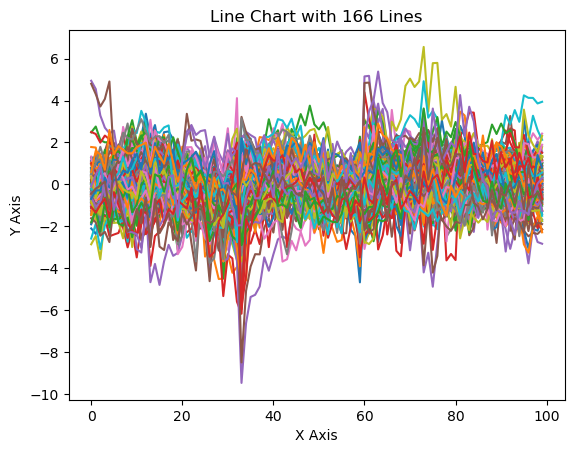

In [79]:
sub_beta_series = roi_betas_arr[6, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

Z trial plot

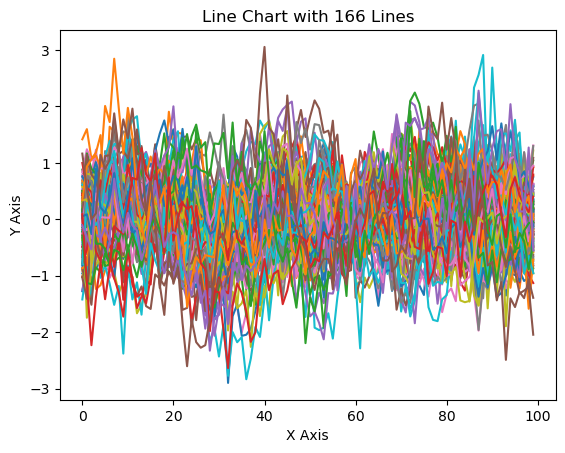

In [74]:
sub_beta_series = roi_z_arr[3, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

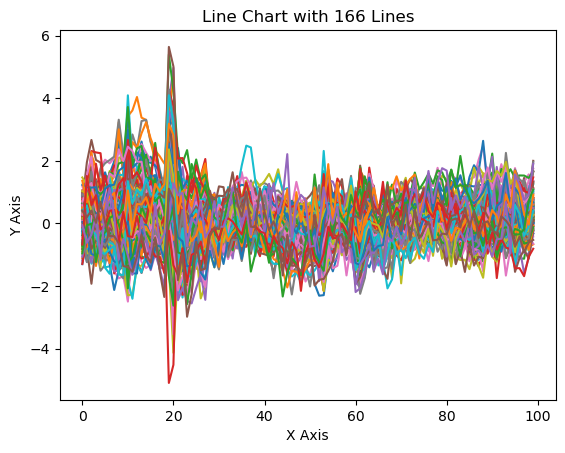

In [75]:
sub_beta_series = roi_z_arr[4, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

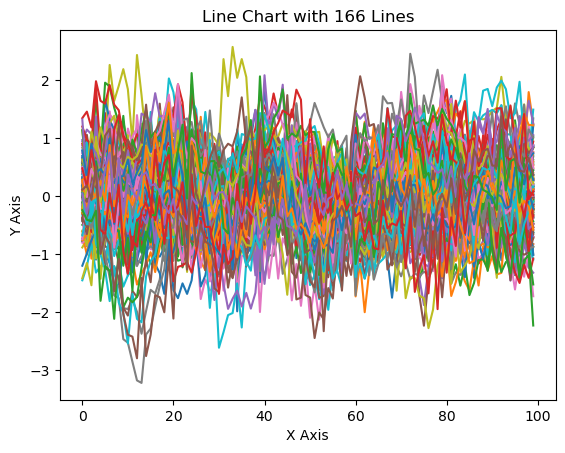

In [76]:
sub_beta_series = roi_z_arr[5, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

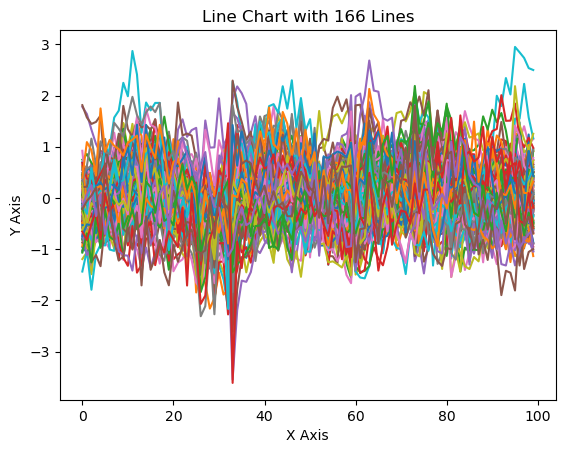

In [73]:
sub_beta_series = roi_z_arr[6, :, :]
sub_beta_series.shape
x = np.arange(100)
# Plot each line
for i in range(sub_beta_series.shape[1]):
    plt.plot(x, sub_beta_series[:100, i])

# Add labels and title
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Chart with 166 Lines')

# Show the plot
plt.show()

In [25]:
np.count_nonzero(np.isnan(roi_betas_arr))

0

In [65]:
np.where(np.isnan(roi_betas_arr[0,0,:]))


(array([34, 35, 80, 81], dtype=int64),)

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\param_validation.py:72: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=0.5 
  warnings.warn("The given float value must not exceed {0}. "
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\find_cuts.py:69: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  warnings.warn(



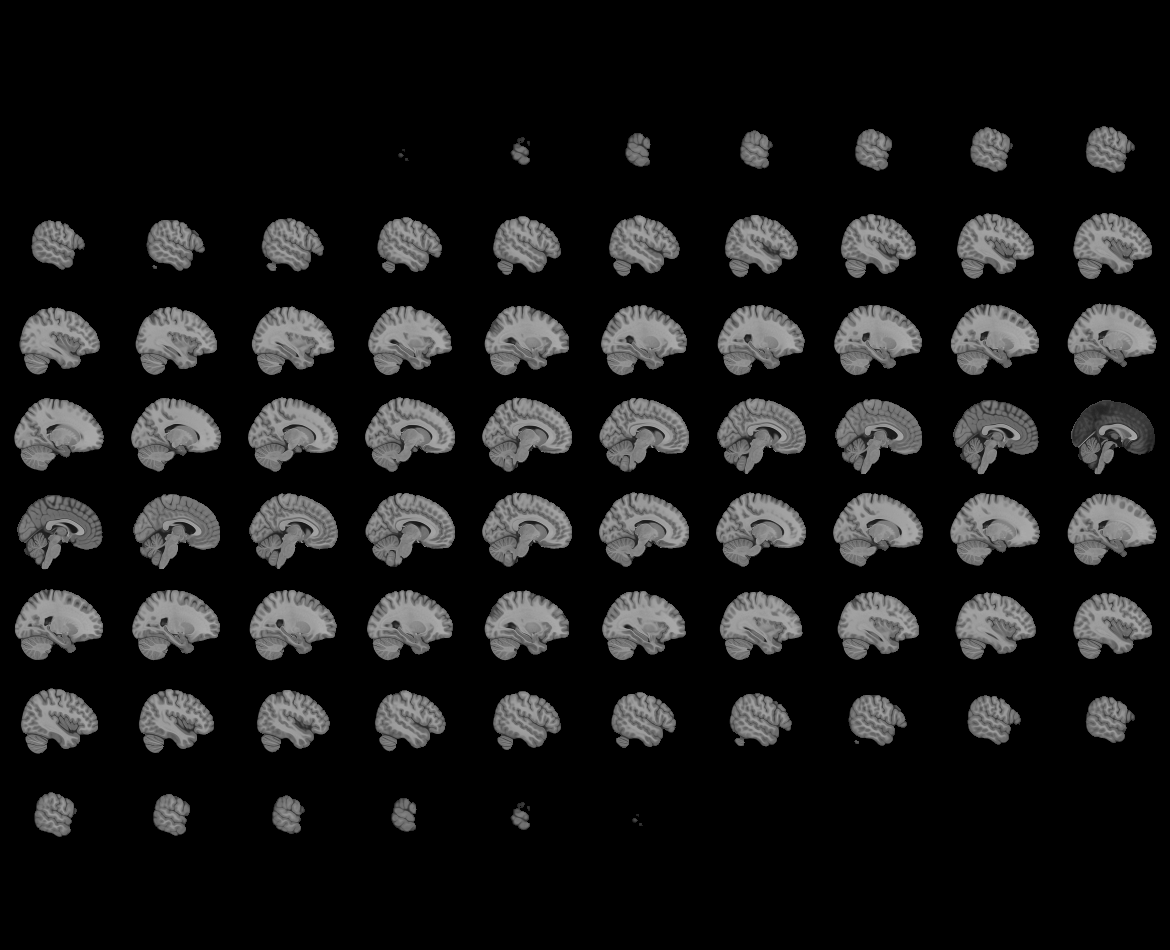
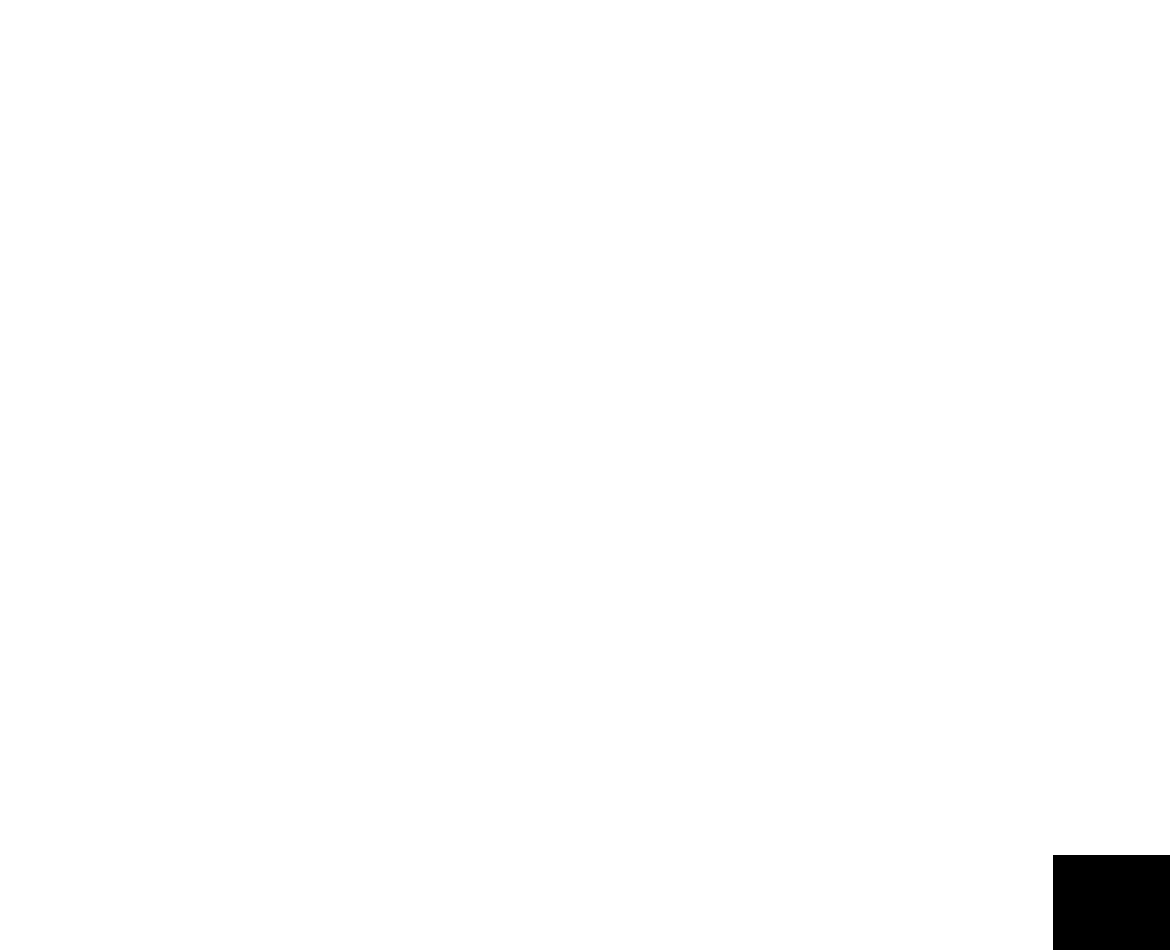

In [70]:

# Create a mask where the value equals 1
mask_data = aal3_resample.get_fdata()
mask = (mask_data == 81)

# Apply the mask to the NIfTI data
masked_data = mask_data * mask

# Create a new NIfTI image with the masked data
masked_img = nib.Nifti1Image(masked_data, affine=temp_nii_data.affine)

# Plot the masked image using nilearn
plotting.view_img(masked_img, threshold=0.5, cmap='gray', draw_cross=False, title='Regions where value equals 1', annotate=False)

#### Check masked z series

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



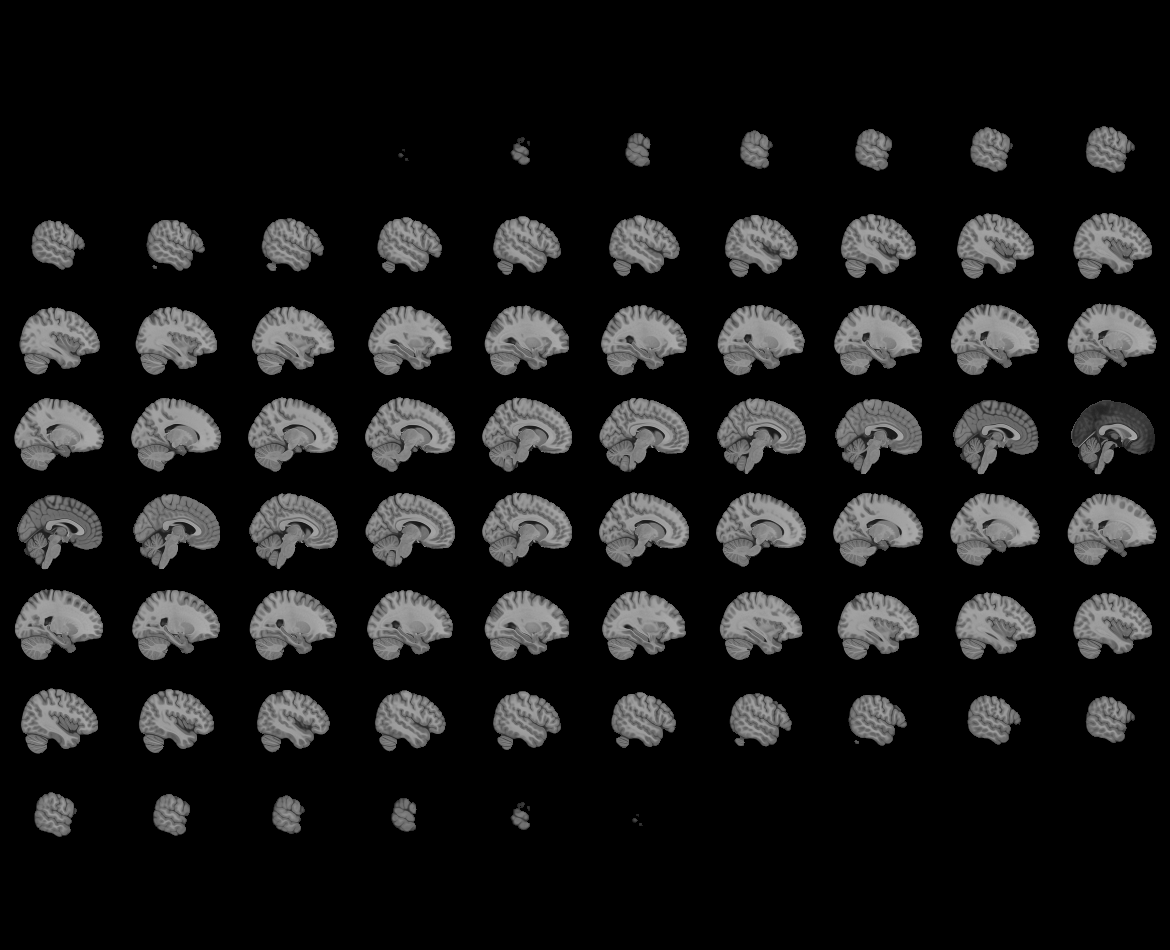
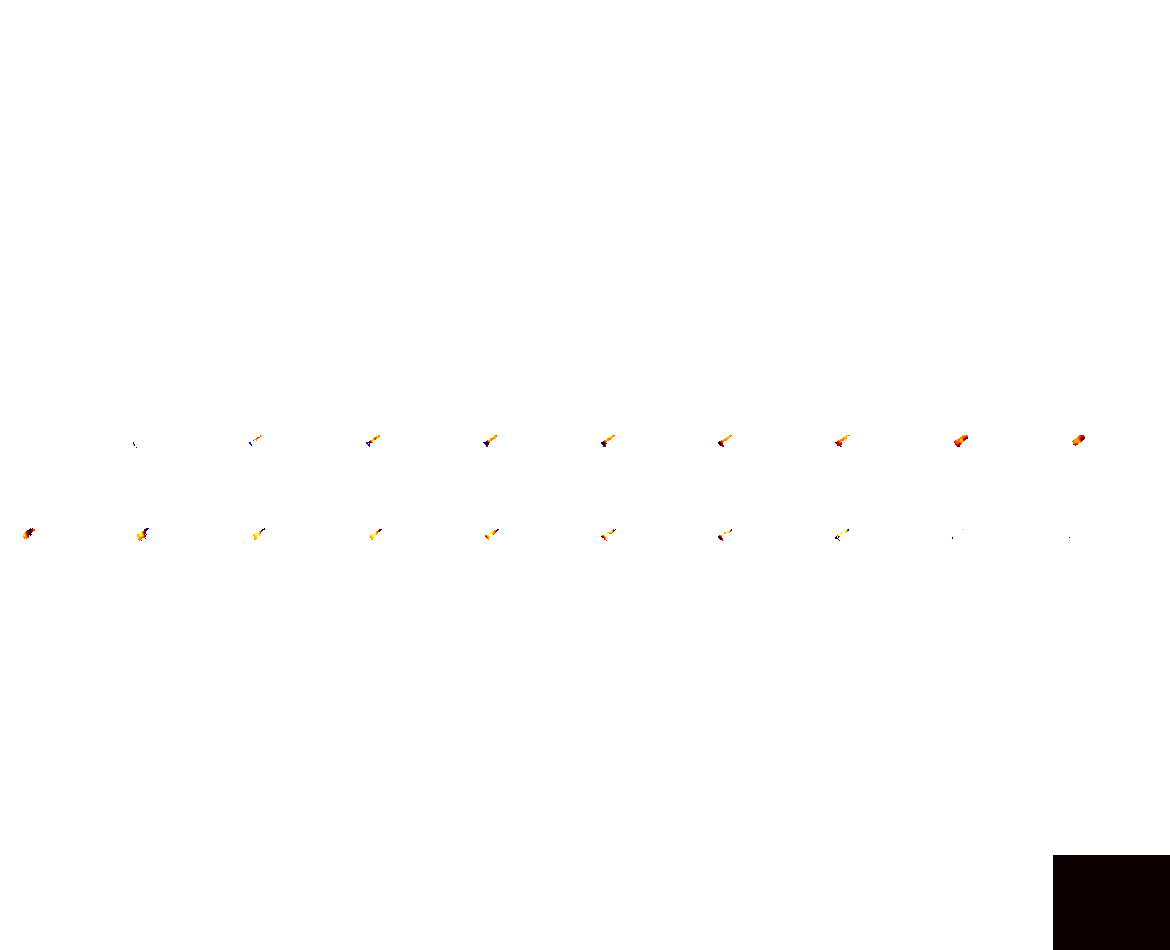

In [39]:
# z_series_arr_test = z_series_arr[1,100,:]
# z_series_arr_test_1d = z_series_arr_test.flatten()
# # z_series_arr_test_1d = z_series_arr_test.flatten(order = 'F')

# flat_roi_data = roi_masks['V1v'].get_fdata()
# # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
# roi_flat = flat_roi_data.flatten()
# # roi_flat = flat_roi_data.flatten(order = 'F')
# indices = np.where(roi_flat)[0]
# roi_betas = np.squeeze(z_series_arr_test_1d)[indices]

# test_mask_data = np.empty((79, 95, 79))
# test_mask_data[:] = np.nan
# test_mask_data_flat = test_mask_data.flatten()
# test_mask_data_flat[indices] = roi_betas
# # With no F order
# from nilearn.image import new_img_like
# test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
# view = plotting.view_img(test_mask_nii)
# view


# Load stimuli sequence

In [19]:
stim_dir = 'F:\yujun\projects\LAB_IAPS_AI\data\stimulus_v2'
stim_files = natsorted(os.listdir(stim_dir))
stim_files

['r1.txt',
 'r2.txt',
 'r3.txt',
 'r4.txt',
 'r5.txt',
 'r6.txt',
 'r7.txt',
 'r8.txt',
 'r9.txt',
 'r10.txt']

In [20]:
stimuli = []
for i, file in enumerate(stim_files):
    txt_path = os.path.join(stim_dir, file)
    data_array = np.loadtxt(txt_path, dtype=str)
    stimuli.append(data_array)
stimuli = np.array(stimuli).flatten()

Add stimuli types

In [21]:
stim_types = pd.read_csv('F:\yujun\projects\LAB_IAPS_AI\data\iaps_emotion_category_v2.csv')
stim_types

,id,iaps_id,img,emotion_type,AI,group
0,1205,1205,1205.jpg,unpleasant,NO,unpleasant
1,1205_2,1205,1205_2.jpg,unpleasant,YES,unpleasantAI
2,1270,1270,1270.jpg,unpleasant,NO,unpleasant
3,1270_0,1270,1270_0.jpg,unpleasant,YES,unpleasantAI
4,1419,1419,1419.jpg,neutral,NO,neutral
...,...,...,...,...,...,...
115,9900_2,9900,9900_2.jpg,unpleasant,YES,unpleasantAI
116,9905,9905,9905.jpg,unpleasant,NO,unpleasant
117,9905_2,9905,9905_2.jpg,unpleasant,YES,unpleasantAI
118,9909,9909,9909.jpg,unpleasant,NO,unpleasant


In [22]:
stimuli_df = pd.DataFrame({'Sequence': stimuli})
# Add an 'OriginalOrder' column to the df DataFrame
stimuli_df['OriginalOrder'] = stimuli_df.index
stimuli_df

,Sequence,OriginalOrder
0,2045_2.jpg,0
1,6211_0.jpg,1
2,5395_2.jpg,2
3,3230_0.jpg,3
4,2550.jpg,4
...,...,...
595,3016_1.jpg,595
596,9140.jpg,596
597,2446.jpg,597
598,9570_1.jpg,598


In [23]:
# Merge the two DataFrames based on the StimulusID column
merged_df = stimuli_df.merge(stim_types, left_on='Sequence', right_on='img')
# Sort the merged DataFrame based on the 'OriginalOrder' column
merged_df = merged_df.sort_values(by='OriginalOrder')
stimuli = merged_df[['OriginalOrder','img','emotion_type', 'AI', 'group']].reset_index(drop=True)
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [120]:
stimuli.to_csv("./stimuli_600trials.csv")

In [28]:
type(stimuli)

pandas.core.frame.DataFrame

# SVM

In [26]:
roi_betas_arr.shape

(2, 600, 166)

## Within subject decoding

In [24]:
decode_ids = []
decode_names = []

decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('PL vs. Nt (natrual) images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
# decode_names.append('Pl vs. Up (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('Up vs. Nt (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Pl vs. Nt (AI) images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
# decode_names.append('Pl vs. Up (AI) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Up vs. Nt (AI) images.')

decode_dict = dict(zip(decode_names, decode_ids))

In [25]:
decode_dict['PL vs. Nt (natrual) images.']

array([  4,   6,  15,  16,  18,  19,  24,  26,  30,  31,  32,  37,  39,
        41,  43,  47,  48,  51,  55,  56,  61,  62,  64,  65,  67,  71,
        72,  73,  74,  80,  93,  99, 100, 102, 108, 109, 110, 113, 116,
       117, 122, 126, 129, 132, 136, 138, 141, 142, 146, 151, 157, 162,
       164, 168, 170, 171, 172, 174, 177, 178, 185, 186, 190, 194, 197,
       202, 206, 207, 208, 209, 210, 211, 215, 218, 220, 223, 227, 231,
       233, 239, 243, 249, 252, 254, 259, 262, 265, 267, 268, 270, 271,
       272, 273, 276, 277, 280, 281, 282, 290, 293, 301, 304, 308, 312,
       318, 319, 321, 323, 328, 335, 336, 338, 340, 342, 344, 346, 347,
       354, 356, 357, 361, 365, 367, 370, 372, 383, 384, 386, 394, 398,
       400, 401, 403, 404, 407, 409, 411, 412, 416, 419, 422, 423, 425,
       427, 428, 430, 431, 434, 435, 441, 445, 446, 448, 449, 454, 458,
       459, 462, 464, 469, 484, 487, 489, 491, 497, 500, 501, 503, 504,
       505, 507, 513, 514, 518, 519, 523, 529, 530, 534, 537, 54

In [27]:
decode_dict['Up vs. Nt (natrual) images.']

array([  6,  11,  15,  16,  22,  24,  28,  31,  32,  34,  37,  38,  44,
        48,  51,  52,  53,  55,  57,  59,  60,  62,  64,  65,  67,  69,
        72,  73,  80,  81,  84,  89,  95, 100, 103, 104, 107, 109, 110,
       111, 120, 122, 127, 129, 131, 132, 133, 134, 135, 136, 146, 147,
       150, 161, 162, 164, 168, 169, 171, 178, 180, 182, 189, 190, 194,
       195, 198, 200, 205, 209, 210, 218, 220, 223, 227, 228, 231, 232,
       235, 239, 243, 244, 246, 254, 255, 260, 261, 265, 271, 276, 280,
       281, 282, 283, 285, 288, 289, 290, 293, 295, 307, 308, 310, 315,
       316, 318, 319, 320, 321, 323, 327, 337, 341, 342, 346, 351, 352,
       354, 356, 357, 361, 363, 368, 369, 371, 372, 379, 382, 383, 386,
       387, 396, 399, 402, 403, 404, 409, 411, 412, 416, 422, 424, 425,
       427, 431, 434, 437, 438, 443, 451, 452, 458, 459, 462, 463, 464,
       469, 470, 471, 477, 480, 482, 484, 487, 488, 489, 490, 493, 494,
       495, 497, 501, 513, 514, 518, 520, 533, 534, 537, 539, 54

In [28]:
decode_dict['Pl vs. Nt (AI) images.']

array([  0,   2,   5,   8,   9,  10,  13,  14,  23,  25,  27,  29,  33,
        35,  36,  42,  46,  49,  50,  54,  63,  66,  70,  75,  79,  83,
        85,  86,  87,  88,  90,  96,  97,  98, 101, 106, 112, 115, 118,
       119, 121, 123, 124, 125, 130, 139, 140, 144, 145, 154, 155, 158,
       159, 160, 163, 165, 166, 175, 176, 179, 181, 184, 188, 191, 193,
       201, 203, 204, 213, 214, 217, 219, 222, 225, 229, 230, 234, 236,
       237, 238, 241, 242, 245, 247, 251, 257, 258, 263, 264, 269, 274,
       275, 278, 284, 286, 291, 292, 294, 298, 299, 300, 302, 303, 306,
       309, 313, 314, 317, 322, 326, 329, 330, 331, 334, 343, 345, 349,
       350, 355, 358, 364, 373, 374, 375, 377, 378, 380, 381, 385, 388,
       390, 392, 393, 395, 405, 406, 410, 413, 414, 417, 426, 429, 439,
       440, 442, 450, 453, 455, 456, 457, 460, 461, 465, 466, 468, 474,
       475, 476, 478, 479, 481, 483, 485, 492, 496, 498, 502, 508, 509,
       510, 511, 512, 515, 517, 524, 525, 526, 531, 535, 536, 54

In [22]:
decode_dict['Up vs. Nt (AI) images.']

array([  1,   2,   3,   5,   7,  10,  12,  13,  14,  17,  20,  21,  23,
        29,  33,  40,  45,  49,  50,  58,  66,  68,  70,  75,  76,  77,
        78,  82,  83,  86,  88,  91,  92,  94,  96, 105, 106, 112, 114,
       118, 121, 123, 128, 130, 137, 140, 143, 144, 148, 149, 152, 153,
       154, 156, 159, 163, 166, 167, 173, 175, 181, 183, 187, 188, 192,
       193, 196, 199, 201, 212, 216, 219, 221, 224, 226, 229, 230, 234,
       237, 238, 240, 242, 245, 248, 250, 251, 253, 256, 258, 263, 266,
       269, 275, 278, 279, 287, 296, 297, 298, 299, 300, 303, 305, 311,
       314, 324, 325, 329, 330, 331, 332, 333, 339, 343, 345, 348, 350,
       353, 358, 359, 360, 362, 364, 366, 373, 375, 376, 377, 380, 385,
       389, 390, 391, 392, 393, 397, 408, 410, 415, 418, 420, 421, 426,
       432, 433, 436, 439, 444, 447, 453, 456, 457, 460, 466, 467, 472,
       473, 474, 476, 478, 481, 485, 486, 492, 496, 499, 506, 508, 509,
       511, 515, 516, 521, 522, 526, 527, 528, 532, 536, 538, 54

In [34]:
decode_ids[0].shape

(200,)

In [49]:
subs

['Sub7_archive', 'Sub7']

In [50]:
np.count_nonzero(np.isnan(roi_betas_arr) )

0

In [56]:
# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

decode_acc = []

for s in range(len(subs)):
    # print(f'Now decoding {roi_name}')
    cases = []
    for i, (decode_name, decode_id) in enumerate(tqdm(decode_dict.items())):
        data = roi_betas_arr[s, decode_id, :]
        labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)
        repeats = []
        for train_index, test_index in rskf.split(data, labels):
            X_train, X_test = data[train_index], data[test_index]
            y_train, y_test = labels[train_index], labels[test_index]

            # Create SVC classifiers with different kernels
            linear_svc = SVC(kernel='linear', random_state=42)

            # Fit the model
            linear_svc.fit(X_train, y_train)

            # Evaluate the model
            linear_score = linear_svc.score(X_test, y_test)
            repeats.append(linear_score)
        cases.append(np.array(repeats))
    decode_acc.append(np.array(cases))

100%|██████████| 4/4 [00:05<00:00,  1.30s/it]


In [65]:
len(y_train)

175

In [58]:
decode_acc_arr = np.array(decode_acc)
decode_acc_arr.shape

(14, 4, 80)

In [59]:

decode_acc_avg = np.mean(decode_acc_arr, axis=2)
decode_acc_avg.shape

(14, 4)

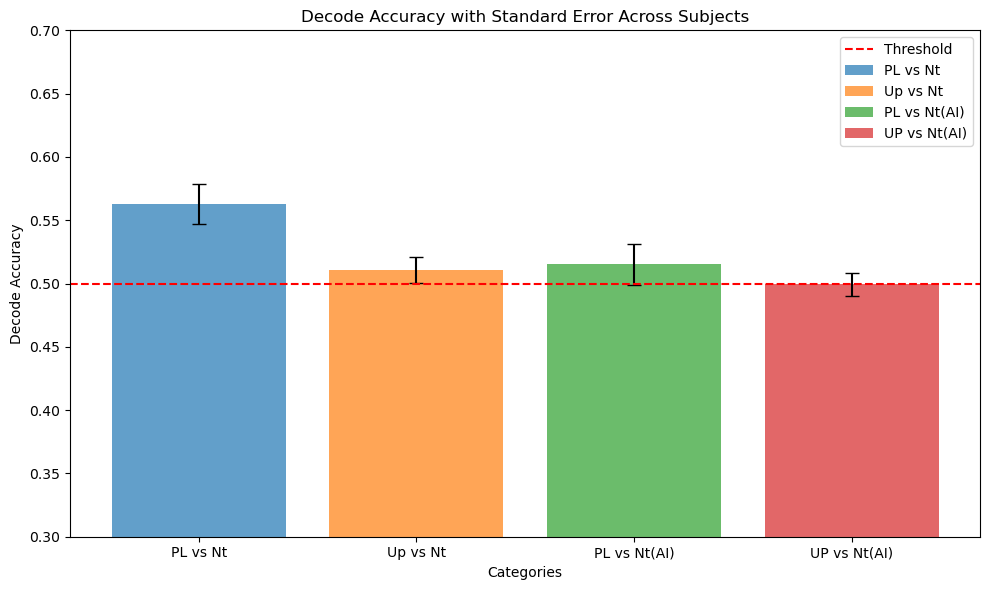

In [116]:


# Calculate the mean and standard error across subjects for each category
mean_decode_acc = np.mean(decode_acc_avg, axis=0)
se_decode_acc = np.std(decode_acc_avg, axis=0) / np.sqrt(decode_acc_avg.shape[0])

# Define the categories
categories = ['PL vs Nt', 'Up vs Nt', 'PL vs Nt(AI)', 'UP vs Nt(AI)']

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each category with error bars
for i, category in enumerate(categories):
    # Plot the bar chart
    ax.bar(i, mean_decode_acc[i], yerr=se_decode_acc[i], capsize=5, label=category, align='center', alpha=0.7)

# Set labels and title
ax.set_xlabel('Categories')
ax.set_ylabel('Decode Accuracy')
ax.set_title('Decode Accuracy with Standard Error Across Subjects')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)

# Set y-axis limits
ax.set_ylim(0.3, 0.7)

# Add horizontal line at y = 0.5
ax.axhline(y=0.5, color='red', linestyle='--', label='Threshold')


# Add legend
ax.legend()

# Show plot
plt.tight_layout()
plt.show()


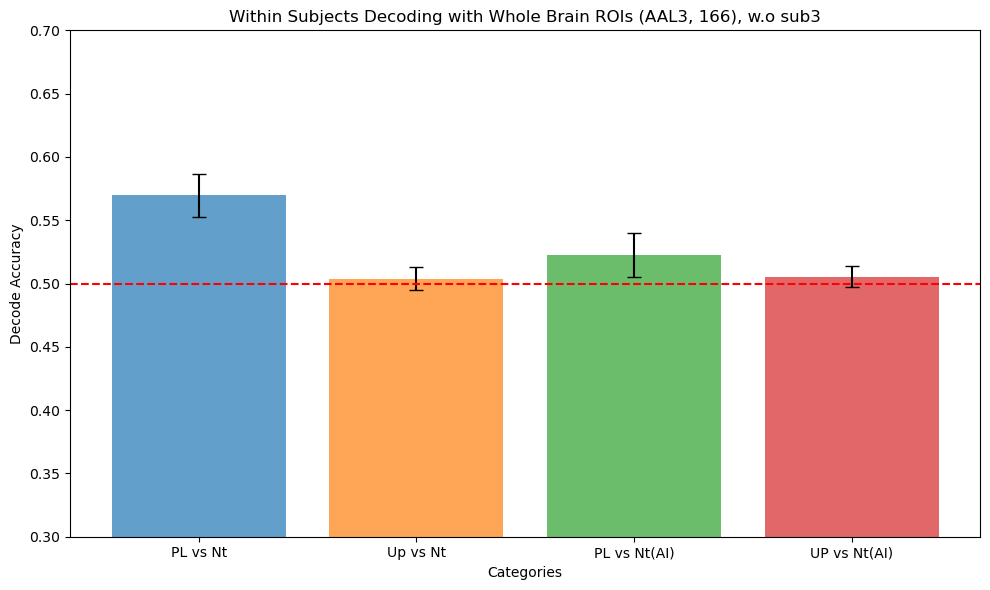

In [142]:
decode_acc_avg2 = np.delete(decode_acc_avg, 2, axis=0)

# Calculate the mean and standard error across subjects for each category
mean_decode_acc = np.mean(decode_acc_avg2, axis=0)
se_decode_acc = np.std(decode_acc_avg2, axis=0) / np.sqrt(decode_acc_avg2.shape[0])

# Define the categories
categories = ['PL vs Nt', 'Up vs Nt', 'PL vs Nt(AI)', 'UP vs Nt(AI)']

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each category with error bars
for i, category in enumerate(categories):
    # Plot the bar chart
    ax.bar(i, mean_decode_acc[i], yerr=se_decode_acc[i], capsize=5, label=category, align='center', alpha=0.7)

# Set labels and title
ax.set_xlabel('Categories')
ax.set_ylabel('Decode Accuracy')
ax.set_title('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166), w.o sub3')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)

# Set y-axis limits
ax.set_ylim(0.3, 0.7)

# Add horizontal line at y = 0.5
ax.axhline(y=0.5, color='red', linestyle='--', label='Threshold')


# Add legend
# ax.legend()

# Show plot
plt.tight_layout()
plt.show()

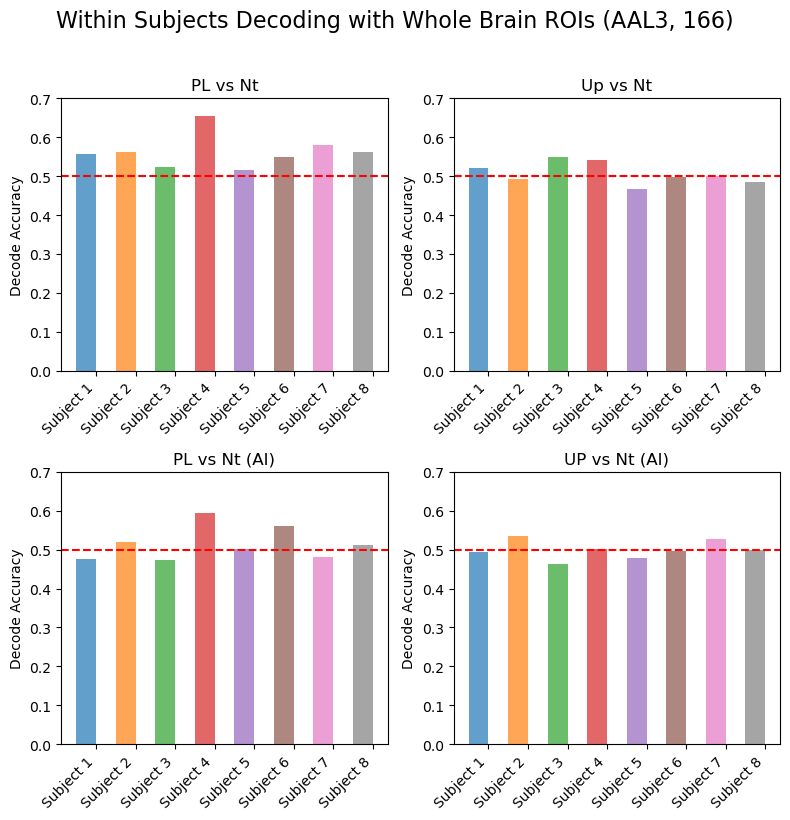

In [197]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'Subject {subj_idx + 1}' for subj_idx in range(decode_acc_avg.shape[0])], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

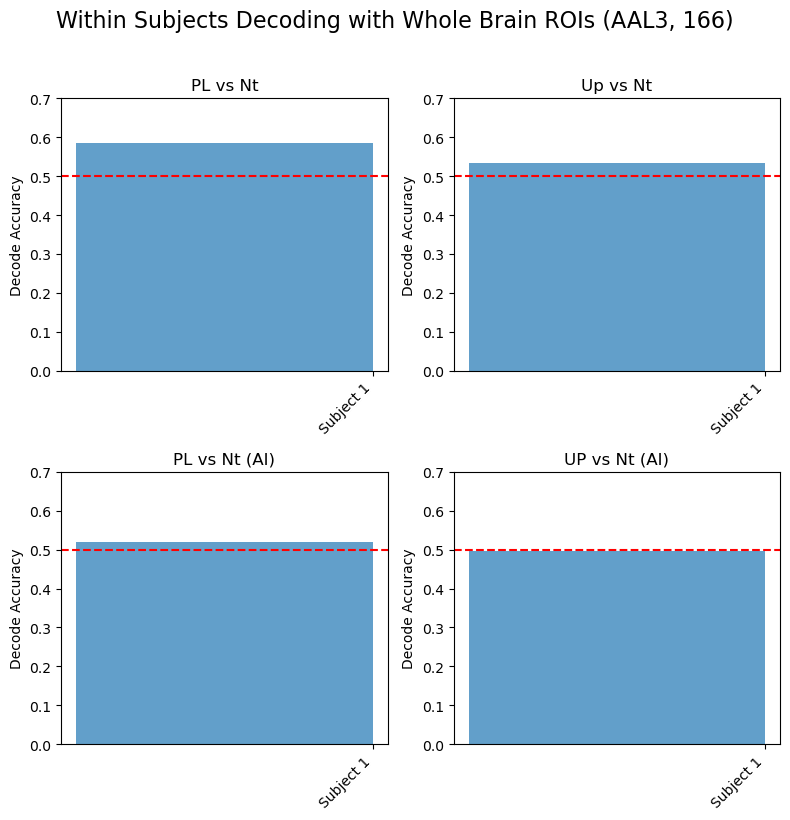

In [39]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'Subject {subj_idx + 1}' for subj_idx in range(decode_acc_avg.shape[0])], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

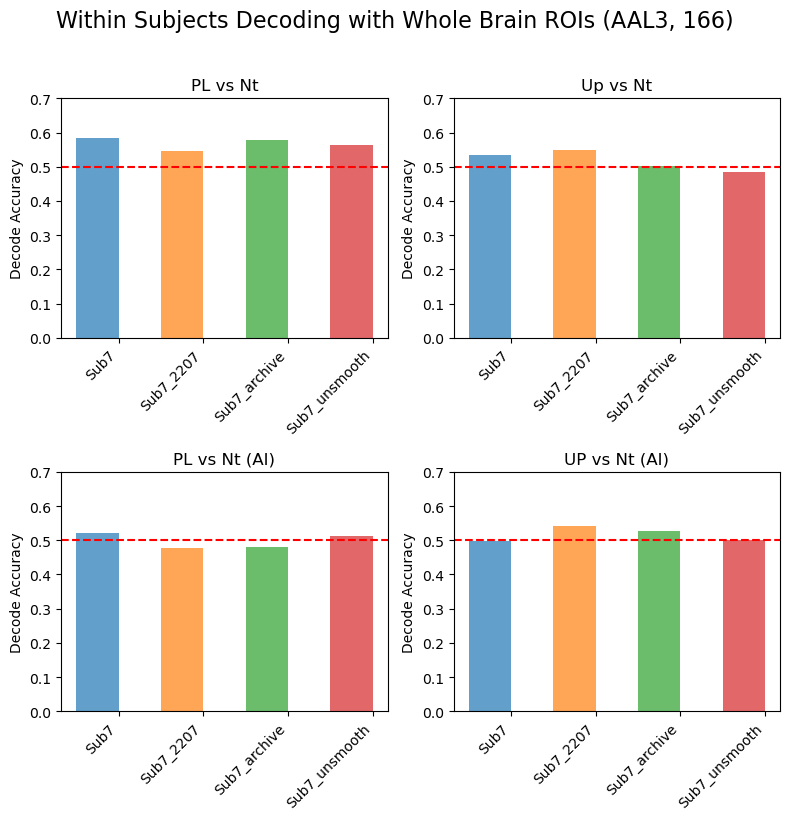

In [26]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'{sub}' for sub in subs], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

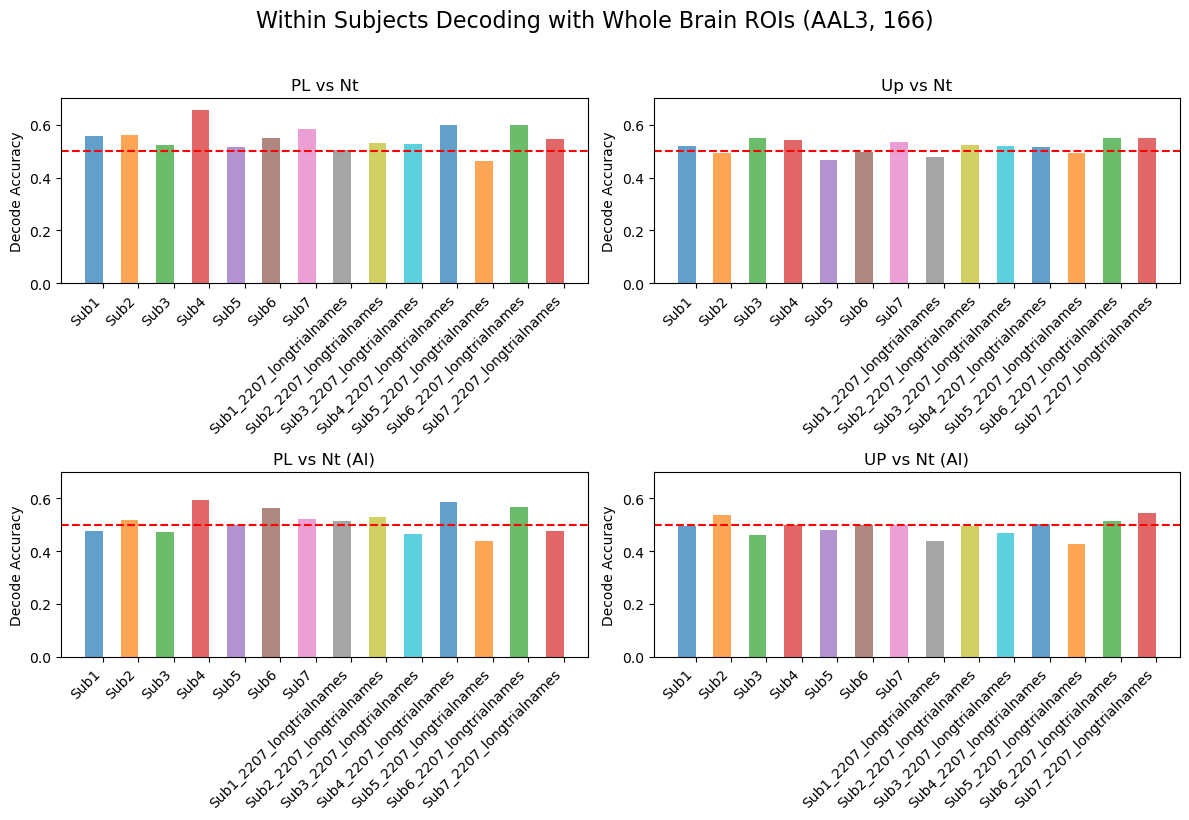

In [32]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'{sub}' for sub in subs], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

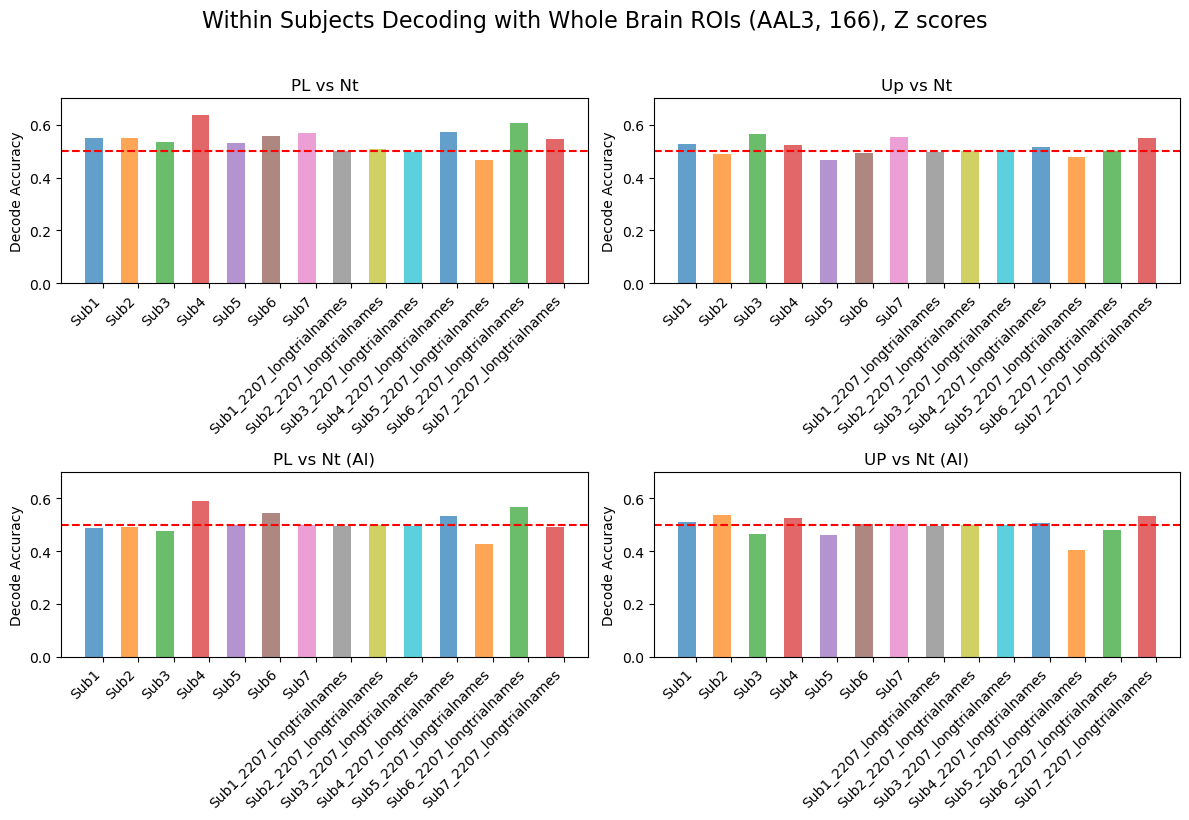

In [53]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'{sub}' for sub in subs], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166), Z scores', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

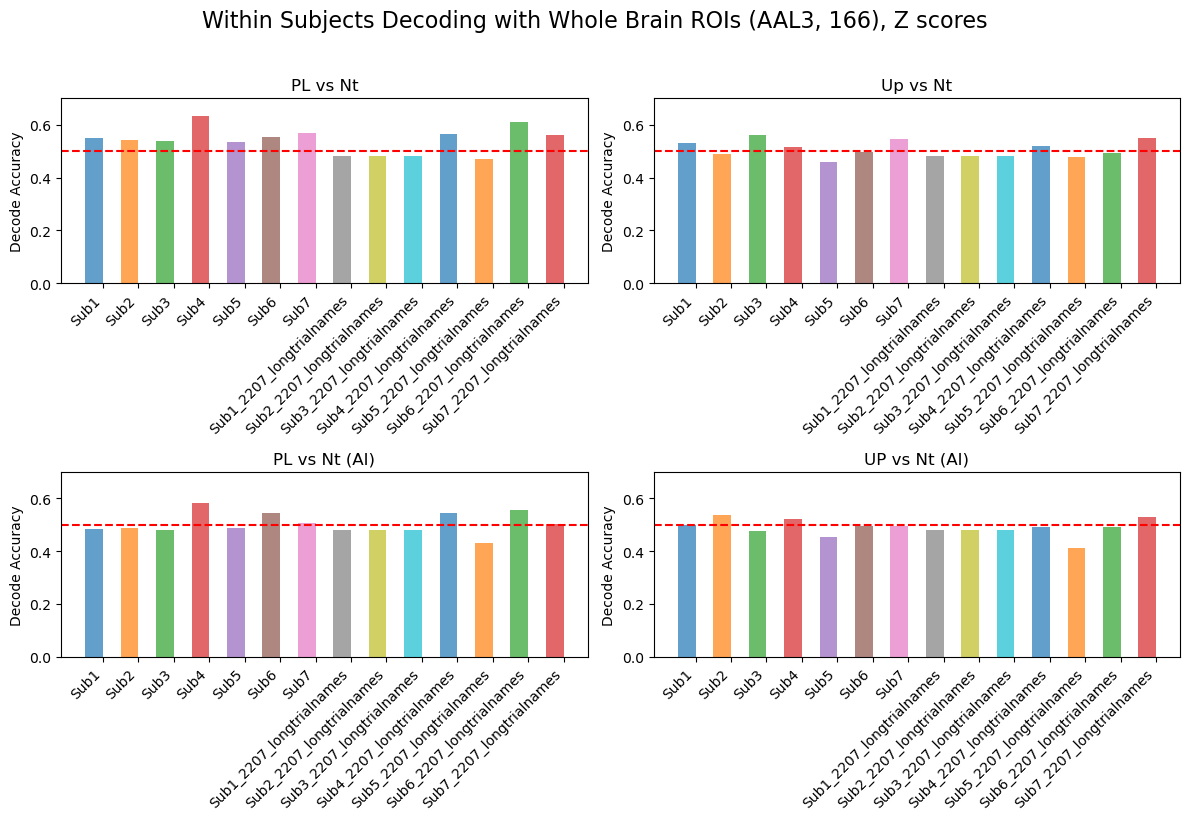

In [61]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'{sub}' for sub in subs], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166), Z scores', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

Random test

In [234]:
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from tqdm import tqdm

# Define decode_names and create decode_dict as you did before

# Define the number of repetitions for random labels
num_repeats = 15

# Stratified 10-fold cross-validation
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=num_repeats, random_state=42)

decode_acc = []


for _ in range(num_repeats):
    classes = ["type 1", "type 2", "type 3"]
    np.random.shuffle(classes)

    # Select the first two classes from the shuffled list
    class1, class2 = classes[:2]

    # Generate random labels with a balanced distribution of the two selected classes
    half_size = 100
    random_labels = np.concatenate((np.full(half_size, class1), np.full(half_size, class2)))
    np.random.shuffle(random_labels)
    
    # Perform decoding with random labels
    decode_acc_repeat = []

    for s in tqdm(range(len(subs))):
        cases = []
        for i, (decode_name, decode_id) in enumerate(decode_dict.items()):
            data = roi_betas_arr[s, decode_id, :]
            labels = random_labels
            repeats = []
            for train_index, test_index in rskf.split(data, labels):
                X_train, X_test = data[train_index], data[test_index]
                y_train, y_test = labels[train_index], labels[test_index]

                # Create SVC classifiers with different kernels
                linear_svc = SVC(kernel='linear', random_state=42)

                # Fit the model
                linear_svc.fit(X_train, y_train)

                # Evaluate the model
                linear_score = linear_svc.score(X_test, y_test)
                repeats.append(linear_score)
            cases.append(np.array(repeats))
        decode_acc_repeat.append(np.array(cases))
    
    decode_acc.append(decode_acc_repeat)

# decode_acc now contains accuracy values for each repetition of decoding with random labels


100%|██████████| 8/8 [02:18<00:00, 17.37s/it]


In [235]:
decode_acc_arr = np.array(decode_acc)
decode_acc_avg_ = np.mean(decode_acc_arr, axis=3)
decode_acc_avg = np.mean(decode_acc_avg_, axis=0)
decode_acc_avg.shape

(8, 4)

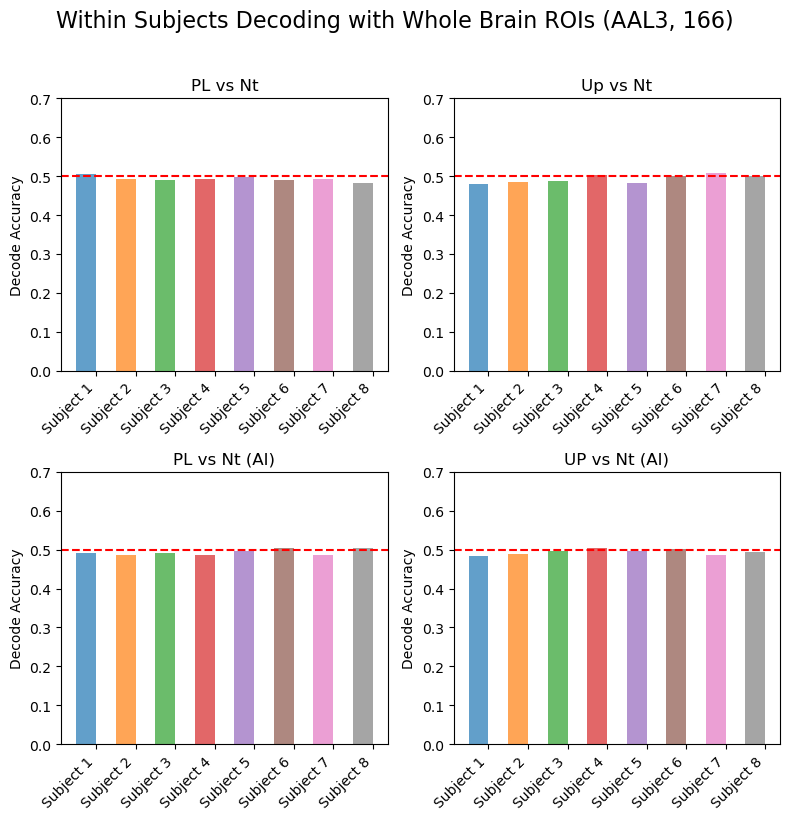

In [237]:
# Define the categories
categories = ['PL vs Nt', 
              'Up vs Nt', 
              'PL vs Nt (AI)', 
              'UP vs Nt (AI)']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(decode_acc_avg.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, decode_acc_avg[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.7)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(decode_acc_avg.shape[0]))
    axes[i].set_xticklabels([f'Subject {subj_idx + 1}' for subj_idx in range(decode_acc_avg.shape[0])], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Add title to the entire figure
fig.suptitle('Within Subjects Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=16, y=1.02)
# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [117]:
np.save( "./outputs/global_decoding_accuracy_7subs.npy", decode_acc_avg)

## Within-subject, cross-condition Decoding

In [119]:
roi_betas_arr.shape

(7, 600, 166)

In [118]:
xdecode_ids = []
xdecode_names = []

xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
# xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
# xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])

xdecode_names.append('Pleasant vs. Neutral, trained on natural and tested on AI')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on natural and tested on AI')
xdecode_names.append('Unpleasant vs. Neutral, trained on natural and tested on AI')
xdecode_names.append('Pleasant vs. Neutral, trained on AI and tested on natrual')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on AI and tested on natrual')
xdecode_names.append('Unpleasant vs. Neutral, trained on AI and tested on natrual')

In [120]:
xd_sub = []
for s in range(len(subs)):

    cases = []
    for i, xdecode_id in enumerate(tqdm(xdecode_ids)):

        data_train = roi_betas_arr[s, xdecode_id, :]
        label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
        if i == 0:
            data_test = roi_betas_arr[s, xdecode_ids[2], :]
            label_test = stimuli['emotion_type'][xdecode_ids[2]].reset_index(drop=True)
        elif i == 1:
            data_test = roi_betas_arr[s, xdecode_ids[3], :]
            label_test = stimuli['emotion_type'][xdecode_ids[3]].reset_index(drop=True)
        elif i == 2:
            data_test = roi_betas_arr[s, xdecode_ids[0], :]
            label_test = stimuli['emotion_type'][xdecode_ids[0]].reset_index(drop=True)
        else:
            data_test = roi_betas_arr[s, xdecode_ids[1], :]
            label_test = stimuli['emotion_type'][xdecode_ids[1]].reset_index(drop=True)

        # Create SVC classifiers with different kernels
        linear_svc = SVC(kernel='linear')

        # Fit the model
        linear_svc.fit(data_train, label_train)

        # Evaluate the model
        linear_score = linear_svc.score(data_test, label_test)

        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(linear_score)

    xd_sub.append(np.array(cases))



100%|██████████| 4/4 [00:00<00:00, 25.12it/s]


In [121]:
xd_arr = np.array(xd_sub)
xd_arr.shape

(7, 4)

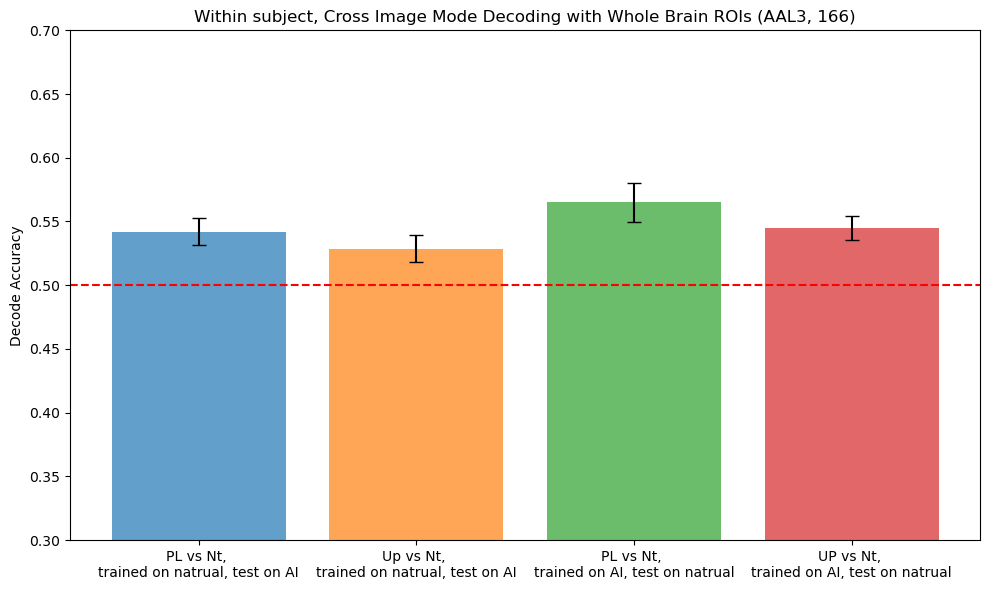

In [137]:
# Calculate the mean and standard error across subjects for each category
mean_decode_acc = np.mean(xd_arr, axis=0)
se_decode_acc = np.std(xd_arr, axis=0) / np.sqrt(xd_arr.shape[0])

# Define the categories
categories = ['PL vs Nt, \ntrained on natrual, test on AI', 'Up vs Nt, \ntrained on natrual, test on AI', 'PL vs Nt, \ntrained on AI, test on natrual', 'UP vs Nt, \ntrained on AI, test on natrual']

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each category with error bars
for i, category in enumerate(categories):
    # Plot the bar chart
    ax.bar(i, mean_decode_acc[i], yerr=se_decode_acc[i], capsize=5, label=category, align='center', alpha=0.7)

# Set labels and title
# ax.set_xlabel('Categories')
ax.set_ylabel('Decode Accuracy')
ax.set_title('Within subject, Cross Image Mode Decoding with Whole Brain ROIs (AAL3, 166)')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)

# Set y-axis limits
ax.set_ylim(0.3, 0.7)

# Add horizontal line at y = 0.5
ax.axhline(y=0.5, color='red', linestyle='--', label='Threshold')


# # Add legend
# ax.legend()

# Show plot
plt.tight_layout()
plt.show()


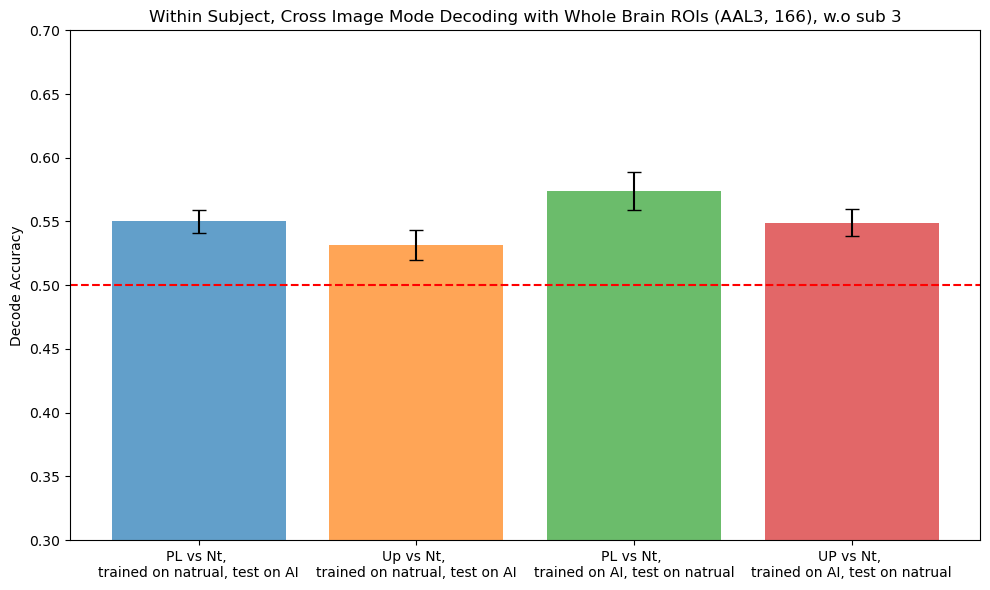

In [141]:
# Calculate the mean and standard error across subjects for each category
xd_arr2 = np.delete(xd_arr, 2, axis=0)
mean_decode_acc = np.mean(xd_arr2, axis=0)
se_decode_acc = np.std(xd_arr2, axis=0) / np.sqrt(xd_arr2.shape[0])

# Define the categories
categories = ['PL vs Nt, \ntrained on natrual, test on AI', 'Up vs Nt, \ntrained on natrual, test on AI', 'PL vs Nt, \ntrained on AI, test on natrual', 'UP vs Nt, \ntrained on AI, test on natrual']

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each category with error bars
for i, category in enumerate(categories):
    # Plot the bar chart
    ax.bar(i, mean_decode_acc[i], yerr=se_decode_acc[i], capsize=5, label=category, align='center', alpha=0.7)

# Set labels and title
# ax.set_xlabel('Categories')
ax.set_ylabel('Decode Accuracy')
ax.set_title('Within Subject, Cross Image Mode Decoding with Whole Brain ROIs (AAL3, 166), w.o sub 3')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)

# Set y-axis limits
ax.set_ylim(0.3, 0.7)

# Add horizontal line at y = 0.5
ax.axhline(y=0.5, color='red', linestyle='--', label='Threshold')


# # Add legend
# ax.legend()

# Show plot
plt.tight_layout()
plt.show()

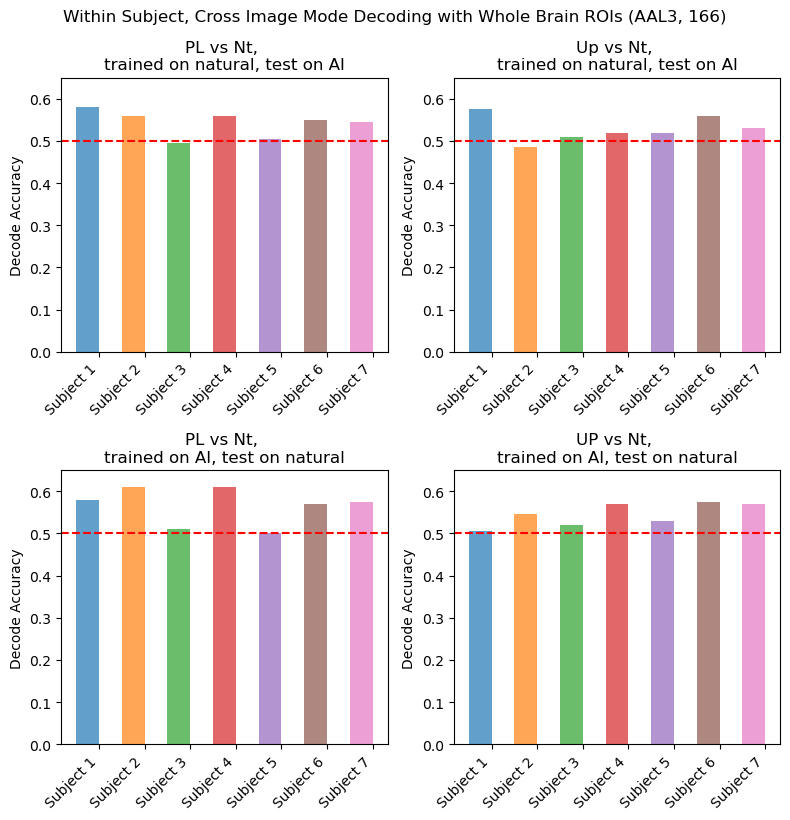

In [167]:
# Define the categories
categories = ['PL vs Nt, \ntrained on natural, test on AI', 
              'Up vs Nt, \ntrained on natural, test on AI', 
              'PL vs Nt, \ntrained on AI, test on natural', 
              'UP vs Nt, \ntrained on AI, test on natural']

# Set up the figure and axis
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each category
for i, category in enumerate(categories):
    # Plot each subject's decode accuracy
    for subj_idx in range(xd_arr.shape[0]):
        x = subj_idx - 0.25  # Adjust the position of bars for each subject
        axes[i].bar(x, xd_arr[subj_idx, i], width=0.5, label=f'Subject {subj_idx + 1}', align='center', alpha=0.7)

    # Set labels and title
    axes[i].set_ylabel('Decode Accuracy')
    axes[i].set_title(category)

    # Set y-axis limits
    axes[i].set_ylim(0, 0.65)

    # Set x-axis ticks and labels
    axes[i].set_xticks(range(xd_arr.shape[0]))
    axes[i].set_xticklabels([f'Subject {subj_idx + 1}' for subj_idx in range(xd_arr.shape[0])], rotation=45, ha='right')

    # Add horizontal line at y = 0.5
    axes[i].axhline(y=0.5, color='red', linestyle='--', label='Threshold')

    # # Add legend
    # axes[i].legend()

# Adjust layout
plt.tight_layout()

# Add title to the entire figure
fig.suptitle('Within Subject, Cross Image Mode Decoding with Whole Brain ROIs (AAL3, 166)', fontsize=12, y=1.02)

# Show plot
plt.show()